# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [127]:
# importar librerías

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [128]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [129]:
plans.head() # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [130]:
users.head() # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [131]:
usage.head() # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [132]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [133]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [134]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [135]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [136]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos
print(users.isna().mean()) # Proporción de valores nulos

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [137]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  En el dataset de users se evidencia valores faltantes en las columnas de city con una proporcion del 11% y en churn_date con un 88%. Mientras en usage se identificaron valores ausentes en las columnas de date con un 0,01%, duration con un 55% y length con 44%.
- Indica qué harías: ¿imputar, eliminar, ignorar?
  En el caso de users daría un manejo diferente a cada una de las columnas, por ejemplo: para la columna de churn_date cuya proporcion de valores faltantes se encuentra por encima del 80% la ignoraría o eliminaría (dicha proporción me puede indicar que por ejemplo se trata de solo unos cuantos clientes que han terminado su suscripción de servicio). Por otro lado, para la columna de city que cuenta con una proporcion de valores nulos de 11% recurriría a investigar para proceder a imputar o dejar como nulos dichos valores.
  En cuanto al dataset de usage realizaría para la columna date (0,01%) una simple imputacion, mientras que para las columnas de duration y lenght, al tratarse de proporciones importantes en métricas claves para responder a la pregunta del negocio, investigaría primer para luego decidir si los imputo o dejo como nulos. 

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [138]:
# explorar columnas numéricas de users
users.describe() 

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`: Los valores van de 10,000 a 13,999, un rango de exactamente 4,000 valores enteros consecutivos para 4,000 registros → no hay huecos ni duplicados. La media (11,999.5) coincide exactamente con la mediana (50% = 11,999.5), lo que indica una distribución perfectamente simétrica y uniforme. La desviación estándar (~1,154) es consistente con una distribución uniforme en ese rango.No hay anomalías. Es un ID autogenerado, secuencial y sin problemas de calidad.

- La columna `age` : Valor mínimo de -999! esto es claramente un valor centinela o de relleno. Probablemente se usó -999 para representar datos faltantes o desconocidos en lugar de NULL. Esto contamina toda la estadística de la columna. La desviación estándar es altísima (123.23) para una variable de edad, siendo que el rango real (25–75%) es de apenas 32 a 63 años. La media (33.74) está jalada hacia abajo artificialmente por el/los registros con -999.


In [139]:
# explorar columnas numéricas de usage
usage.describe() 

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`: En ID los valores van de 1 a 40,000, exactamente 40,000 registros → rango completo sin huecos ni duplicados. La media (20,000.5) coincide perfectamente con la mediana (50% = 20,000.5) → distribución uniforme y simétrica.
La std (~11,547) es consistente con una distribución uniforme en ese rango. ID autogenerado, secuencial y sin anomalías. Todo en orden.Para user_id el rango va de 10,000 a 13,999, este dataset tiene 40,000 registros, es decir, 10 veces más filas que usuarios únicos → cada usuario aparece múltiples veces en promedio (~10 registros por usuario). La media (12,002) y la mediana (12,013) son muy cercanas, lo que sugiere que los usuarios están representados de forma relativamente balanceada, sin que un grupo domine excesivamente. 
- Las columnas 'duration' y 'length': En 'duration' el primer dato que salta a la vista es que hay un problema de completitud severo: el count es 17,924 sobre 40,000 registros totales → más del 55% de los valores están ausentes. Esto es una alerta crítica de calidad de datos. El mínimo es 0.0 → existen sesiones o eventos con duración cero, lo que puede significar registros erróneos, clics accidentales o eventos que nunca se completaron. El máximo de 120 con una media de 5.2 y una mediana de 3.5 indica una distribución muy sesgada hacia la derecha, con la mayoría de eventos siendo cortos pero con algunos casos extremos largos. La std (6.84) siendo mayor que la media (5.20) confirma ese sesgo y la presencia de valores atípicos en el extremo alto. En cuanto a 'lengtg' se observan también datos incompletos pero en menor medida, el count es 22,104 sobre 40,000 → aproximadamente 45% de valores faltantes. Igualmente preocupante. El mínimo es 0 y el máximo es 1,490, con una media de 52.1 y una mediana de 50 → la distribución es más simétrica que duration, pero el valor máximo de 1,490 sugiere la presencia de outliers significativos. La std (56.6) siendo similar a la media (52.1) indica dispersión considerable. 

In [140]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe() 

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city`: Count de 3,531 sobre 4,000 → hay 469 valores faltantes (~12% de missing). No es crítico pero merece atención.
Solo 7 ciudades únicas → es una variable de baja cardinalidad, lo que es ideal para segmentación y análisis por grupos.
La ciudad más frecuente es Bogotá con 808 apariciones, lo que representa apenas el ~23% del total válido → la distribución entre ciudades parece relativamente balanceada, ninguna ciudad domina de forma aplastante.
- La columna `plan`: Count de 4,000 → sin valores faltantes. Esta columna está completamente llena, lo que sugiere que es un campo obligatorio en el sistema. Solo 2 valores únicos → variable binaria (por ejemplo: Basic / Premium, o Free / Paid).
El plan "Basico" aparece 2,595 veces → representa el ~65% de los usuarios, frente a un ~35% en el otro plan.

In [141]:
# explorar columna categórica de usage
usage['type'].describe()  # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type`: Count de 40,000 → sin valores faltantes. Campo completamente lleno, probablemente obligatorio en el sistema.
Solo 2 valores únicos → variable binaria, y el valor más frecuente es "text". El tipo "text" aparece 22,092 veces → representa el ~55% de los registros, con el otro tipo (llamadas)  cubriendo el ~45% restante. Una distribución bastante equilibrada entre ambas categorías.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels? y como se aboradarían?
De todas las columnas analizadas, solo age (del dataset users) contiene un valor verdaderamente inválido (-999 como centinela), que debe corregirse de inmediato. Los nulos en duration y length (en usage) resultan ser esperados y explicables por el tipo de contenido, por lo que no requieren imputación sino una estrategia de análisis separado por tipo. El resto de las columnas están en buen estado y los dos datasets están correctamente relacionados a través de user_id.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [142]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [143]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [144]:
# Revisar los años presentes en `reg_date` de users
print("Distribución de años en reg_date:")
print(users['reg_date'].dt.year.value_counts().sort_index())

Distribución de años en reg_date:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


In [145]:

#el tipo de dato sigue sin ser formato de fecha:
#verifico el tipo de dato actual 
print("Tipo de dato actual:", users['reg_date'].dtype)
print("Muestra de valores:", users['reg_date'].head())
#forzo la conversión correcta:
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
#verifico que ahora sea datetime:
print("Nuevo tipo:", users['reg_date'].dtype)


Tipo de dato actual: datetime64[ns]
Muestra de valores: 0   2022-01-01 00:00:00.000000000
1   2022-01-01 06:34:17.914478619
2   2022-01-01 13:08:35.828957239
3   2022-01-01 19:42:53.743435858
4   2022-01-02 02:17:11.657914478
Name: reg_date, dtype: datetime64[ns]
Nuevo tipo: datetime64[ns]


En `reg_date` existen 40 registros con año 2026, y la fecha máxima encontrada es 2026-05-10. Estos son valores fuera de rango porque si los datos fueron recolectados hasta 2024, un registro de 2026 es imposible, nadie puede registrarse en el futuro.
Representan apenas el 1% del total (40/4,000), pero son suficientes para distorsionar cualquier análisis temporal de cohortes. Fue necesario incluir un refuerzo de la conversión a formato de fecha ya que en el resumen aparecia tipo de dato numérico y esto me impedia avanzar en la limpieza.

In [146]:
# Revisar los años presentes en `date` de usage
print("Distribución de años en date:")
print(usage['date'].dt.year.value_counts(dropna=False).sort_index())
# También revisar el rango completo de fechas
print(f"\nFecha mínima: {usage['date'].min()}")
print(f"Fecha máxima: {usage['date'].max()}")

Distribución de años en date:
2024.0    39950
NaN          50
Name: date, dtype: int64

Fecha mínima: 2024-01-01 00:00:00
Fecha máxima: 2024-06-30 00:00:00


In [147]:
#el tipo de dato sigue sin ser formato de fecha:
#verifico el tipo de dato actual 
print("Tipo de dato actual:", usage['date'].dtype)
print("Muestra de valores:", usage['date'].head())
#forzo la conversión correcta:
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')
#verifico que ahora sea datetime:
print("Nuevo tipo:", usage['date'].dtype)


Tipo de dato actual: datetime64[ns]
Muestra de valores: 0   2024-01-01 00:00:00.000000000
1   2024-01-01 00:06:30.969774244
2   2024-01-01 00:13:01.939548488
3   2024-01-01 00:19:32.909322733
4   2024-01-01 00:26:03.879096977
Name: date, dtype: datetime64[ns]
Nuevo tipo: datetime64[ns]


En `date` todos los valores válidos son 2024 → no hay años fuera de rango, el rango va de 2024-01-01 a 2024-06-30, perfectamente coherente. 50 registros ya son NaN → estos nulos probablemente existían desde la fuente original o se generaron durante la estandarización de fechas. Aqui fue necfesario también el refuerzo de la conversión del tipo de dato para poder avanzar en la limpieza.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) y - ¿Qué harías con ellas?: 
 Sí, aparecen anos imposibles en la columna 'reg_date': los 40 registros de 2026 son casi con certeza errores de captura o de sistema, y no deben usarse en ningún análisis temporal. Marcándolos como pd.NA se preservan los demás campos del usuario sin eliminar toda la fila, que es la decisión más conservadora y correcta. Por otro lado, la columna 'date' está en mejor estado que reg_date. El único punto a investigar son los 50 nulos, revisando si esas filas tienen datos válidos en las demás columnas o si conviene eliminarlas por ser registros incompletos.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [148]:

# Reemplazar -999 por la mediana de age
age_mediana =  users.loc[users['age'] != -999, 'age'].median()
print(f"Mediana de age (sin -999): {age_mediana}")
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
print(users['age'].describe())


Mediana de age (sin -999): 48.0
count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [149]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [150]:
# Marcar fechas futuras como NA para reg_date
fecha_maxima_valida = pd.to_datetime('2024-12-31')

users['reg_date'] = users['reg_date'].where(
    users['reg_date'] <= fecha_maxima_valida, other=pd.NA
)
# Verificar cambios
users['reg_date'].value_counts(dropna=False)

NaN             40
1.712276e+18     1
1.642202e+18     1
1.673738e+18     1
1.666735e+18     1
                ..
1.679652e+18     1
1.646886e+18     1
1.660726e+18     1
1.709958e+18     1
1.647998e+18     1
Name: reg_date, Length: 3961, dtype: int64

In [151]:
#parece que el tipo de dato se cambio al usar where, asi que se procede a la verificacion del tipo de dato
print("Tipo de dato actual:", users['reg_date'].dtype)
print("Muestra de valores:", users['reg_date'].head())
#se verifico un cambio en el tipo de dato asi que se procede a forzar la conversion:
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
# Verificar que ahora sea datetime64[ns]
print("Nuevo tipo:", users['reg_date'].dtype)

Tipo de dato actual: object
Muestra de valores: 0    1640995200000000000
1    1641018857914478619
2    1641042515828957239
3    1641066173743435858
4    1641089831657914478
Name: reg_date, dtype: object
Nuevo tipo: datetime64[ns]


In [152]:
# Verificar si hay fechas futuras en reg_date (posteriores a 2024)
# 1. Verificar cuántos registros se marcaron como NA (eran los futuros)
registros_na = users['reg_date'].isna().sum()
print(f"Registros marcados como NA: {registros_na}")

# 2. Verificar la distribución de años después de la limpieza
print("\nDistribución de años después de la limpieza:")
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

# 3. Confirmar que no quedan años futuros
años_futuros = (users['reg_date'].dt.year > 2024).sum()
print(f"\nRegistros con años futuros restantes: {años_futuros}")


Registros marcados como NA: 40

Distribución de años después de la limpieza:
2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

Registros con años futuros restantes: 0


In [153]:
# Confirmar que el tipo de dato sigue siendo datetime64
print("Tipo de dato final:", users['reg_date'].dtype)


Tipo de dato final: datetime64[ns]


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [154]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [155]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Los nulos en duration y length resultan ser esperados y explicables por el tipo de contenido, por lo que no requieren imputación sino una estrategia de análisis separado por tipo. Los nulos son missing by design, ya que a las llamadas se les puede medir la duracion pero a los mensajes de texto no (asi se explica el 99% de datos nulos en la columna de duración para el tipo 'texto'), así mismo la extensión o length se puede medir en los mensajes de texto pero no en las llamadas (no que explica el 99% de datos nulos en Length para 'call'). 

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [156]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    total_mensajes = ('is_text', 'sum'),
    total_llamadas = ('is_call', 'sum'),
    total_minutos  = ('duration', 'sum')
).reset_index()


# observar resultado
usage_agg.head(3)

,user_id,total_mensajes,total_llamadas,total_minutos
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [157]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'total_mensajes': 'cant_mensajes',
    'total_llamadas': 'cant_llamadas', 
    'total_minutos': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [158]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on= 'user_id', how='inner')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [159]:
# Resumen estadístico de las columnas numéricas
columnas_numericas= ['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']
user_profile[columnas_numericas].describe() 

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.138285,5.524381,4.478120,23.317054
std,17.691541,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [160]:
# Distribución porcentual del tipo de plan
distribucion_plan = user_profile['plan'].value_counts(normalize=True) * 100
print("Distribución porcentual por tipo de plan:")
print(distribucion_plan)

Distribución porcentual por tipo de plan:
Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

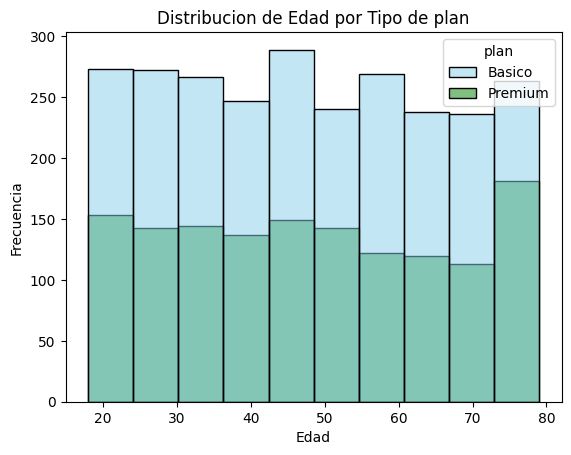

In [161]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', bins=10, palette=['skyblue', 'green'])
plt.title('Distribucion de Edad por Tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
1. El plan Premium es sorprendentemente consistente
La porción verde (Premium) se mantiene estable en aproximadamente 120-150 usuarios en casi todos los rangos de edad, lo que sugiere que la adopción del plan Premium no está fuertemente influenciada por la edad.
2. Los usuarios mayores tienen mayor propensión al Premium
El rango 75-80 años es el más interesante: aunque tiene menos usuarios totales (~180), la proporción Premium es visualmente la más alta de todos los grupos, casi igualando al plan Básico.
3. El rango 55-65 muestra el mayor desbalance. Aquí el plan Básico domina más que en otros rangos, con una porción Premium relativamente baja, lo que podría indicar una oportunidad de conversión en ese segmento.

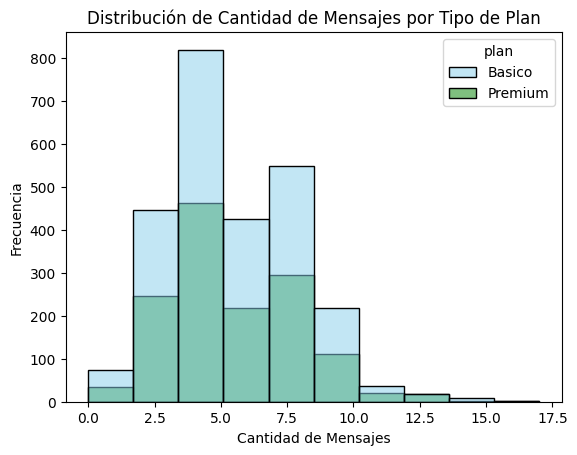

In [162]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=10, palette=['skyblue', 'green'])
plt.title('Distribución de Cantidad de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
1. Los usuarios Premium envían más mensajes
A partir del rango 5-8 mensajes, la proporción verde (Premium) comienza a igualar o superar al plan Básico, mientras que en los rangos bajos (0-5) el Básico domina claramente. Esto sugiere que a mayor uso, mayor probabilidad de tener plan Premium.
2. Los usuarios Básicos dominan el uso bajo
En el rango 0-5 mensajes, el plan Básico es ampliamente mayoritario. Estos son usuarios de baja actividad que posiblemente no perciben suficiente valor para migrar al plan Premium.
3. Los heavy users son casi exclusivamente Premium
En los rangos 10+ mensajes, la porción Premium es proporcionalmente muy alta. Los usuarios que más usan el servicio ya están en el plan correcto.

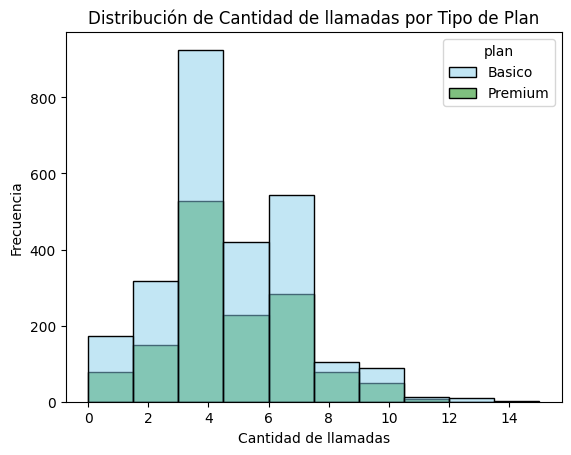

In [163]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=10, palette=['skyblue', 'green'])
plt.title('Distribución de Cantidad de llamadas por Tipo de Plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
1. Patrón muy similar al de mensajes
Al igual que con los mensajes, el plan Básico domina en los rangos bajos (0-4 llamadas), mientras que el Premium gana protagonismo a partir de 5+ llamadas, confirmando que mayor actividad = mayor probabilidad de plan Premium.
2. El rango 6-8 llamadas es el punto de inflexión
Es donde la proporción Premium más se acerca o iguala al Básico, similar a lo observado con los mensajes en el rango 5-8. Esto refuerza la idea de que existe un umbral de uso a partir del cual los usuarios migran o son candidatos a migrar al plan Premium.
3. Usuarios con 0-2 llamadas son casi exclusivamente Básico
Aproximadamente el 75% de este segmento está en plan Básico, siendo usuarios de muy baja actividad telefónica.

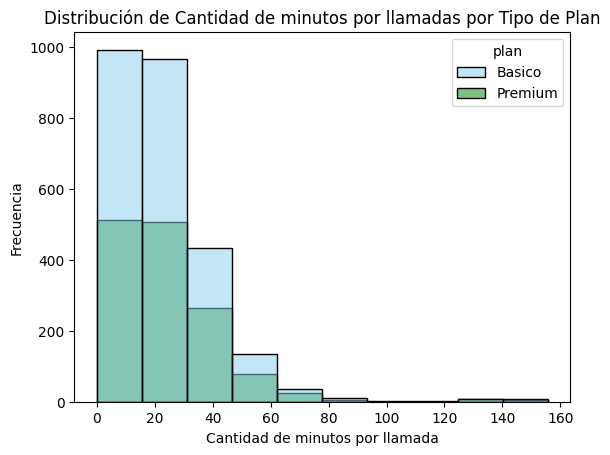

In [164]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=10, palette=['skyblue', 'green'])
plt.title('Distribución de Cantidad de minutos por llamadas por Tipo de Plan')
plt.xlabel('Cantidad de minutos por llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
1. Este es el histograma más revelador de los tres
A diferencia de mensajes y llamadas donde el Básico dominaba en uso bajo, aquí el plan Premium representa aproximadamente el 50% incluso en el rango de menor uso (0-20 minutos). Esto sugiere que los usuarios Premium hacen llamadas independientemente de su duración.
2. A partir de 30 minutos el Premium domina claramente
En los rangos 30-60 minutos la proporción Premium supera visiblemente al Básico, y en 60+ minutos es casi exclusivamente Premium, confirmando que las llamadas largas son territorio Premium.
3. Concentración extrema en rangos bajos
El rango 0-30 minutos acumula más del 80% de todos los usuarios, lo que indica que la mayoría de las llamadas son cortas independientemente del plan.
4. Outliers de alto consumo
Los registros en 120-160 minutos son muy pocos pero casi todos Premium, representando un segmento de usuarios de altísimo consumo telefónico.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

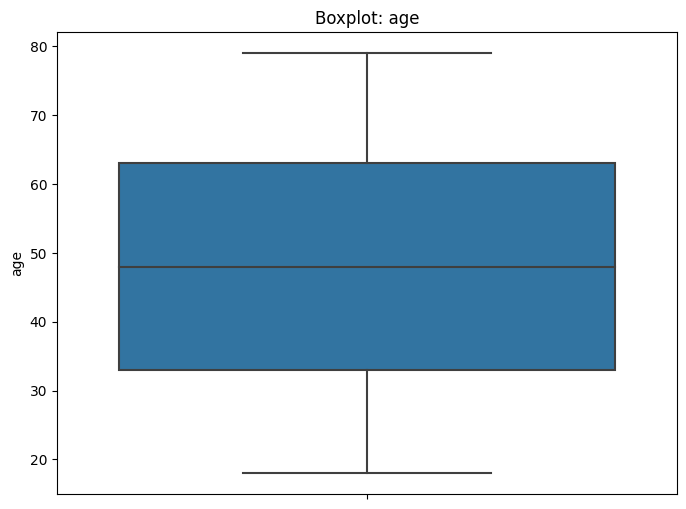

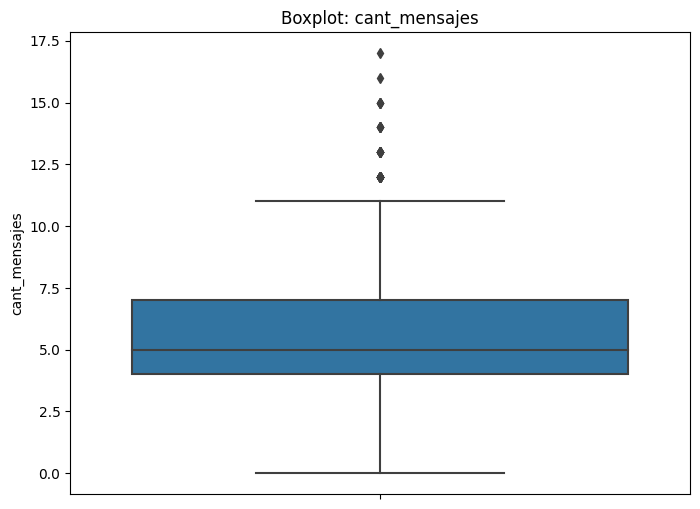

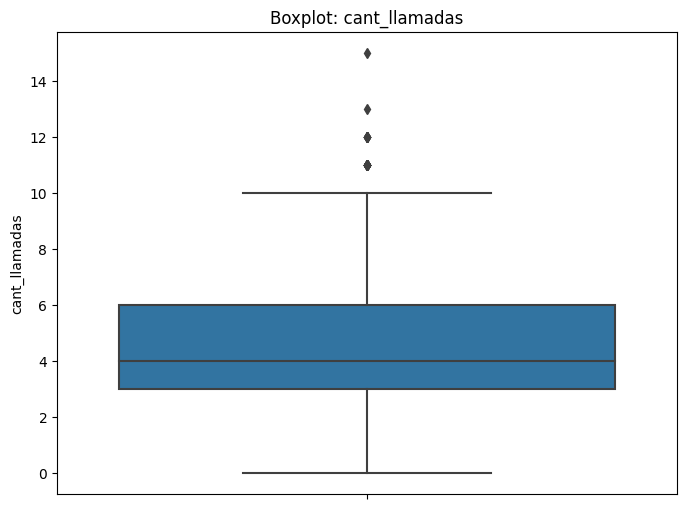

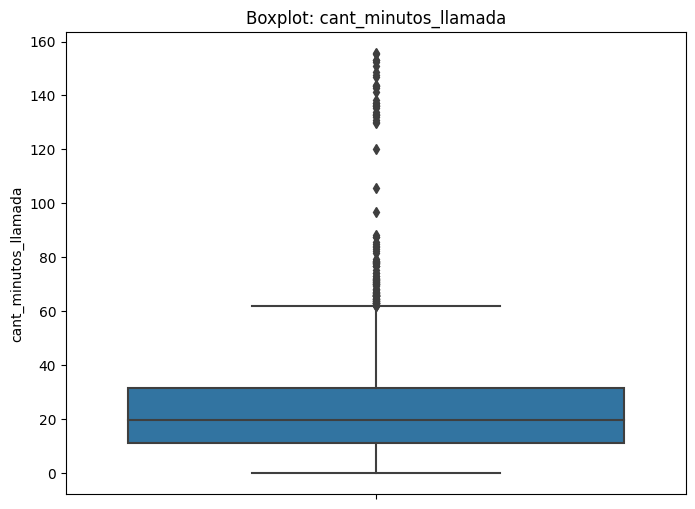

In [165]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=user_profile, y=col)
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
    plt.show()

💡Insights: 
- Age: Sin outliers visibles → la limpieza del centinela -999 fue exitosa.
- cant_mensajes: Presencia de outliers superiores (12-17 mensajes) → minoría de usuarios con actividad inusualmente alta que conviene monitorear.
- cant_llamadas: Pocos outliers (11-15 llamadas) → menos extremos que en mensajes.
- cant_minutos_llamada: Esta es la variable con mayor problema de outliers — nube densa de puntos entre 65 y 160 minutos, con valores extremos muy alejados de la caja.

In [166]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1-1.5* IQR
    limite_superior = Q3+1.5* IQR

    print(f"\n{col}:")
    print(f"  Q1: {Q1:.2f}")
    print(f"  Q3: {Q3:.2f}")
    print(f"  Límite superior: {limite_superior:.2f}")
    print(f"  Valor máximo actual: {user_profile[col].max():.2f}")
    
    # Contar outliers
    outliers = user_profile[col] > limite_superior
    print(f"  Outliers detectados: {outliers.sum()}")


cant_mensajes:
  Q1: 4.00
  Q3: 7.00
  Límite superior: 11.50
  Valor máximo actual: 17.00
  Outliers detectados: 46

cant_llamadas:
  Q1: 3.00
  Q3: 6.00
  Límite superior: 10.50
  Valor máximo actual: 15.00
  Outliers detectados: 30

cant_minutos_llamada:
  Q1: 11.12
  Q3: 31.41
  Límite superior: 61.86
  Valor máximo actual: 155.69
  Outliers detectados: 109


In [167]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
46 outliers por encima de 11.50, valor máximo 17.
La diferencia entre el límite superior (11.50) y el máximo (17) no es dramática.
Son usuarios que simplemente envían más mensajes. Mantener, no son errores de medición sino heavy users reales con valor analítico para segmentación.
- cant_llamadas: mantener o no outliers, porqué?
30 outliers por encima de 10.50, valor máximo 15.
Aún menos outliers que mensajes y la distancia al límite es similar.
Un usuario haciendo 15 llamadas al mes es inusual pero perfectamente posible. Mantener, misma lógica que mensajes, representan un segmento de uso intensivo con información valiosa.
- cant_minutos_llamada: mantener o no outliers, porqué?
109 outliers por encima de 61.86, valor máximo 155.69.
La brecha es enorme, el límite superior es 61 minutos pero el máximo llega a 155 → 2.5 veces el límite. La std (18.17) siendo casi igual a la media (23.32) confirma una dispersión muy alta.
Son muchos outliers y muy extremos.

In [168]:
# procedo a tratar los outliers encontrados en cant_minutos_llamada: winsorizar 
p99 = user_profile['cant_minutos_llamada'].quantile(0.99)
print(f"Límite P99: {p99}")

# Aplicar capping
user_profile['cant_minutos_llamada'] = user_profile['cant_minutos_llamada'].clip(upper=p99)

# Verificar cambios
print(user_profile['cant_minutos_llamada'].describe())

Límite P99: 82.19759999999998
count    3999.000000
mean       22.864377
std        15.822755
min         0.000000
25%        11.120000
50%        19.780000
75%        31.415000
max        82.197600
Name: cant_minutos_llamada, dtype: float64


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [169]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas']<5)&(user_profile['cant_mensajes']<5), 'Bajo uso',
    np.where(
        (user_profile['cant_llamadas']<10)&(user_profile['cant_mensajes']<10), 'Uso medio',
        'Alto uso'
    )
)

In [170]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [171]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    (user_profile['age']<30), 'Joven',
    np.where(
        (user_profile['age']<60), 'Adulto',
        'Adulto_mayor'
    )
)

In [172]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso,Adulto_mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso,Adulto_mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

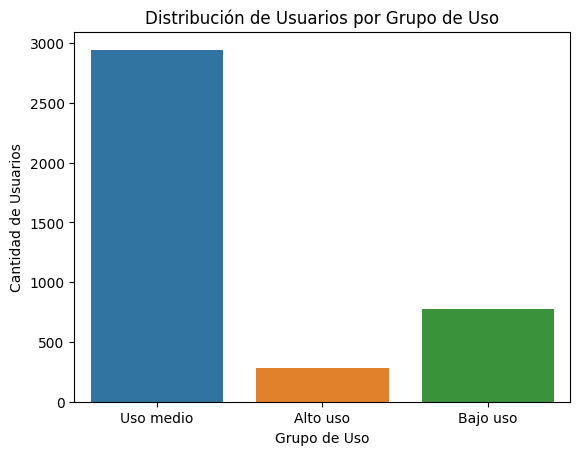

In [173]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()


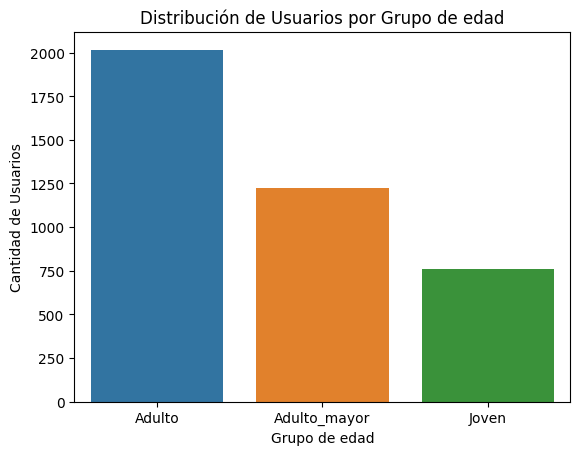

In [174]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de Usuarios por Grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Valor centinela -999 en age (dataset users): registros con edad imposible usados como sustituto de nulos. Fueron reemplazados por la mediana (~47 años) para no distorsionar el análisis estadístico.
- Valor centinela "?" en city (dataset users): 469 registros (~12% de los usuarios) tenían ciudad desconocida. Fueron marcados como pd.NA al no poder imputarse sin introducir sesgo geográfico.
- Fechas futuras en reg_date (dataset users): 40 registros (~1%) tenían año de registro 2026, imposible dado que los datos cubren hasta 2024. Fueron marcados como nulos conservando el resto de la información del usuario.
- Nulos estructurales en duration y length (dataset usage): el 55% y 45% de nulos respectivamente no eran errores sino missing by design, ya que duration solo aplica a llamadas y length solo a mensajes de texto. No requirieron imputación.
- Outliers extremos en cant_minutos_llamada: 109 registros superaban el límite IQR de 61.86 minutos llegando hasta 155.69 minutos. Se aplicó capping en P99 para reducir el impacto sin eliminar variabilidad real.

🔍 **Segmentos por Edad**

- La base de usuarios es amplia y adulta, con mediana de 47 años e IQR entre 34 y 63. Tres grupos fueron definidos: Jóvenes (< 30 años), Adultos (30–59 años) y Adultos Mayores (60+ años), siendo los Adultos el grupo más numeroso.
- La edad no es un predictor fuerte del tipo de plan, ya que la adopción Premium se mantiene estable (~120–150 usuarios) en todos los rangos etarios.
- El segmento 75–80 años es el más valioso proporcionalmente: menor volumen total pero mayor tasa de adopción Premium, lo que sugiere alta satisfacción o mayor poder adquisitivo.
- El rango 55–65 años muestra la mayor dominancia del plan Básico, representando la mayor oportunidad de conversión por tamaño y accesibilidad.

📊 **Segmentos por Nivel de Uso**

- Bajo uso (llamadas < 5 y mensajes < 5): mayoría en plan Básico, baja actividad general. Riesgo latente de churn silencioso.
- Uso medio (llamadas < 10 y mensajes < 10): segmento más numeroso con mezcla equilibrada de planes. Núcleo operativo del negocio y zona de mayor potencial de conversión.
- Alto uso (llamadas ≥ 10 o mensajes ≥ 10): fuerte correlación con plan Premium. Heavy users de alto valor con llamadas de hasta 15 veces al mes y más de 60 minutos acumulados.

➡️ Esto sugiere que el volumen de uso es el predictor más fuerte del tipo de plan, muy por encima de la edad. Existe un umbral claro alrededor de 5 mensajes y 5 llamadas mensuales donde los usuarios Básicos empiezan a comportarse como Premium sin estarlo, lo que representa la zona de conversión más rentable para ConnectaTel.

💡 **Recomendaciones**
- Upsell basado en triggers de actividad: implementar alertas automáticas para usuarios Básicos que superen 5 mensajes o 5 llamadas mensuales. Ese usuario ya tiene el comportamiento Premium, solo necesita el incentivo para migrar.
- Plan intermedio "Plus": la brecha entre Básico y Premium parece amplia para el segmento de uso medio. Un plan con beneficios moderados (más minutos, más mensajes incluidos) capturaría a usuarios que no justifican el salto completo a Premium pero ya superan los límites del Básico.
- Reactivación de usuarios dormidos: los usuarios de bajo uso concentran el mayor riesgo de abandono. Diseñar campañas segmentadas por ciudad y grupo de edad para reactivarlos antes de que cancelen.
- Estrategia diferenciada para Adultos Mayores (60+): este segmento muestra alta adopción Premium de forma orgánica. Investigar sus motivaciones permite replicar esa propuesta de valor en otros grupos etarios.
- Add-on de minutos para heavy callers: los usuarios con 60+ minutos acumulados son casi exclusivamente Premium y de alto valor. Un complemento de minutos extendidos retendría a este segmento crítico y podría atraer a usuarios Básicos con alta duración de llamadas que aún no han migrado.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`